In [132]:
import warnings
warnings.filterwarnings('ignore')

In [133]:
import pandas as pd
import numpy as np

In [134]:
df = pd.read_csv("Data/accepted_2007_to_2018Q4.csv")
df = df.dropna(subset=["loan_status"])
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [135]:
#reduce the data size to fasten following steps, and prevent memory issue
complete_df = df.sample(n=100000, random_state=42)

In [136]:
# Add necessary variables
# Determining the loans that are bad from loan_status column --dependent variable (y)
bad_loan = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "In Grace Period",
            "Late (16-30 days)", "Late (31-120 days)"]
complete_df['loan_condition_int'] = complete_df['loan_status'].apply(lambda status: 1 if status in bad_loan else 0).astype(int)
complete_df['loan_condition'] = np.where(complete_df['loan_condition_int'] == 0, 'Good Loan', 'Bad Loan')

#emp_length
emp_length_mapping = {
    '10+ years': 10,
    '9 years': 9,
    '8 years': 8,
    '7 years': 7,
    '6 years': 6,
    '5 years': 5,
    '4 years': 4,
    '3 years': 3,
    '2 years': 2,
    '1 year': 1,
    '< 1 year': 0.5,
    'n/a': 0
}
complete_df['emp_length_int'] = complete_df['emp_length'].map(emp_length_mapping)
complete_df.head().transpose()

# region
state_to_region = {
    'CA': 'West', 'OR': 'West', 'UT': 'West', 'WA': 'West', 'CO': 'West',
    'NV': 'West', 'AK': 'West', 'MT': 'West', 'HI': 'West', 'WY': 'West', 'ID': 'West',
    'AZ': 'SouthWest', 'TX': 'SouthWest', 'NM': 'SouthWest', 'OK': 'SouthWest',
    'GA': 'SouthEast', 'NC': 'SouthEast', 'VA': 'SouthEast', 'FL': 'SouthEast', 'KY': 'SouthEast',
    'SC': 'SouthEast', 'LA': 'SouthEast', 'AL': 'SouthEast', 'WV': 'SouthEast', 'DC': 'SouthEast',
    'AR': 'SouthEast', 'DE': 'SouthEast', 'MS': 'SouthEast', 'TN': 'SouthEast',
    'IL': 'MidWest', 'MO': 'MidWest', 'MN': 'MidWest', 'OH': 'MidWest', 'WI': 'MidWest',
    'KS': 'MidWest', 'MI': 'MidWest', 'SD': 'MidWest', 'IA': 'MidWest', 'NE': 'MidWest',
    'IN': 'MidWest', 'ND': 'MidWest',
    'CT': 'NorthEast', 'NY': 'NorthEast', 'PA': 'NorthEast', 'NJ': 'NorthEast', 'RI': 'NorthEast',
    'MA': 'NorthEast', 'MD': 'NorthEast', 'VT': 'NorthEast', 'NH': 'NorthEast', 'ME': 'NorthEast'
}
complete_df['region'] = complete_df['addr_state'].map(state_to_region)
complete_df.head().transpose()

,1758074,686539,900731,1727935,539695
id,9785323,78558461,110757806,96668860,118207599
member_id,NaN,NaN,NaN,NaN,NaN
loan_amnt,28000.0,10650.0,18000.0,3975.0,4800.0
funded_amnt,28000.0,10650.0,18000.0,3975.0,4800.0
funded_amnt_inv,28000.0,10650.0,18000.0,3975.0,4800.0
...,...,...,...,...,...
settlement_term,NaN,NaN,NaN,NaN,NaN
loan_condition_int,0,0,0,0,0
loan_condition,Good Loan,Good Loan,Good Loan,Good Loan,Good Loan
emp_length_int,10.0,10.0,9.0,2.0,0.5


### EDA

In [137]:
EDA_df = complete_df.copy()

EDA_cat_columns = EDA_df.select_dtypes(include=['object']).columns.tolist()
EDA_num_columns = EDA_df.select_dtypes(exclude=['object']).columns.tolist()

# Filter categorical columns with unique value count less than or equal to the specified threshold.
filtered_EDA_cat_columns = [col for col in EDA_cat_columns if EDA_df[col].nunique() <= 50]

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_variable_distribution(dataframe, variable_name):
    if dataframe[variable_name].dtype == 'object':
        # Categorical variables, draw a histogram
        sns.countplot(x=variable_name, data=dataframe)
        plt.xlabel(variable_name)
        plt.ylabel('Count')
        plt.title(f'Distribution of {variable_name}')
    else:
        # Numeric variables, plot histograms
        sns.histplot(dataframe[variable_name], kde=True)
        plt.xlabel(variable_name)
        plt.ylabel('Frequency')
        plt.title(f'Distribution of {variable_name}')
    plt.show()

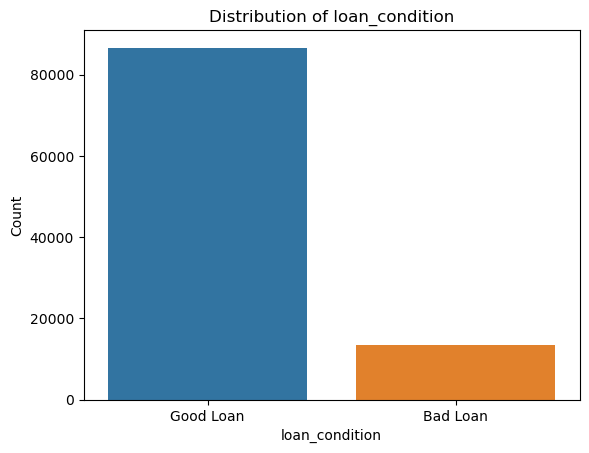

In [139]:
variable = "loan_condition" # @param ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'disbursement_method', 'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term', 'loan_condition_int', 'loan_condition', 'emp_length_int', 'region'] {allow-input: true}
plot_variable_distribution(EDA_df, variable)

In [140]:
def plot_2_variable_relationship(dataframe, x_variable, y_variable):
    if dataframe[x_variable].dtype != 'object' and dataframe[y_variable].dtype != 'object':
        # Two numerical variables, draw a scatter plot
        sns.scatterplot(x=x_variable, y=y_variable, data=dataframe)
        plt.xlabel(x_variable)
        plt.ylabel(y_variable)
        plt.title(f'Scatter Plot: {x_variable} vs. {y_variable}')
    elif dataframe[x_variable].dtype == 'object' and dataframe[y_variable].dtype == 'object':
        # Two categorical variables, draw a crosstab
        cross_tab = pd.crosstab(index=dataframe[x_variable], columns=dataframe[y_variable], normalize='columns') #Show column summary percentage
        sns.heatmap(cross_tab, annot=True, cmap="YlGnBu")
        plt.xlabel(y_variable)
        plt.ylabel(x_variable)
        plt.title(f'Cross Tabulation: {x_variable} vs. {y_variable}')
    elif (dataframe[x_variable].dtype != 'object' and dataframe[y_variable].dtype == 'object') or (dataframe[x_variable].dtype == 'object' and dataframe[y_variable].dtype != 'object'):
        # One categorical variable, one numerical variabl"e, draw a violin plot
        if dataframe[x_variable].dtype != 'object':
            x_variable, y_variable = y_variable, x_variable  # Swap the order of the variables and make sure Y is a numeric variable
        sns.violinplot(x=x_variable, y=y_variable, data=dataframe)
        plt.xlabel(x_variable)
        plt.ylabel(y_variable)
        plt.title(f'Violin Plot: {x_variable} vs. {y_variable}')
        sns.despine()
    else:
        print("Unsupported combination of variable types")

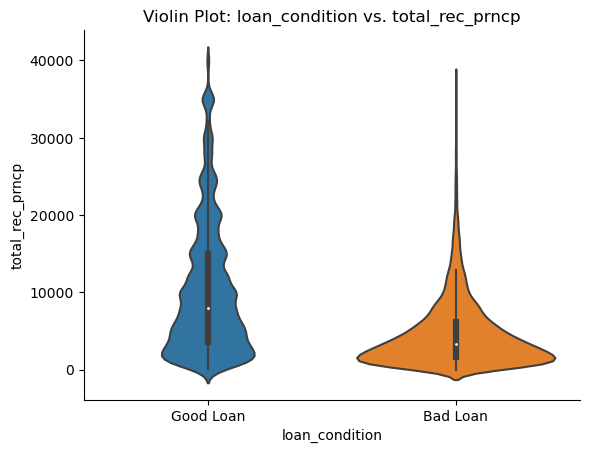

In [141]:
X = "loan_condition" 
Y = "total_rec_prncp"

plot_2_variable_relationship(EDA_df,X,Y) 

In [142]:
def plot_3_variable_relationship(dataframe, x1_variable, x2_variable, y_variable):
    num_types = ['int64', 'float64']

    if (dataframe[x1_variable].dtype == 'object' and
        dataframe[x2_variable].dtype == 'object' and
        dataframe[y_variable].dtype == 'object'):
        # Three categorical variables, draw a crosstab
        cross_tab = pd.crosstab(index=dataframe[x1_variable], columns=[dataframe[x2_variable], dataframe[y_variable]], normalize='columns')
        sns.heatmap(cross_tab, annot=True, cmap="YlGnBu")
        plt.xlabel(f'{x2_variable} - {y_variable}')
        plt.ylabel(x1_variable)
        plt.title(f'Cross Tabulation: {x1_variable} vs. {x2_variable} vs. {y_variable}')
    elif (dataframe[x1_variable].dtype == 'object' and
          dataframe[x2_variable].dtype == 'object' and
          dataframe[y_variable].dtype in num_types):
        # X1 and X2 are categorical, Y is a numerical variable, draw a violin plot or boxplot
        # Example: Drawing a Violin Plot
        sns.violinplot(x=x1_variable, y=y_variable, hue=x2_variable, data=dataframe)
        plt.xlabel(x1_variable)
        plt.ylabel(y_variable)
        plt.title(f'Violin Plot: {x1_variable} vs. {x2_variable} vs. {y_variable}')
    elif (dataframe[x1_variable].dtype in num_types and
          dataframe[x2_variable].dtype in num_types and
          dataframe[y_variable].dtype == 'object'):
        # X1 and X2 are numerical variables, Y is a categorical variable, draw a box plot or violin plot
        # Example: Drawing a Violin Plot
        sns.boxplot(x=x1_variable, y=y_variable, hue=x2_variable, data=dataframe)
        plt.xlabel(x1_variable)
        plt.ylabel(y_variable)
        plt.title(f'Box Plot: {x1_variable} vs. {x2_variable} vs. {y_variable}')
    elif (dataframe[x1_variable].dtype in num_types and
          dataframe[x2_variable].dtype in num_types and
          dataframe[y_variable].dtype in num_types):
        # Three numerical variables, draw a scatter plot
        sns.scatterplot(x=x1_variable, y=x2_variable, hue=y_variable, data=dataframe)
        plt.xlabel(x1_variable)
        plt.ylabel(x2_variable)
        plt.title(f'Scatter Plot: {x1_variable} vs. {x2_variable} vs. {y_variable}')
    elif ((dataframe[x1_variable].dtype == 'object' and dataframe[x2_variable].dtype in num_types) or
          (dataframe[x1_variable].dtype in num_types and dataframe[x2_variable].dtype == 'object')):
        # One of X1 and X2 is a categorical variable and the other is a numerical variable
        if dataframe[y_variable].dtype == 'object':
            # Y is a categorical variable, draw a boxplot or violin plot
            sns.boxplot(x=x1_variable, y=x2_variable, hue=y_variable, data=dataframe)
            plt.xlabel(x1_variable)
            plt.ylabel(x2_variable)
            plt.title(f'Box Plot: {x1_variable} vs. {x2_variable} with Color-Coded {y_variable}')
        elif dataframe[y_variable].dtype in num_types:
            # Y is a numerical variable, draw a box plot or violin plot
            sns.boxplot(x=x1_variable, y=x2_variable, data=dataframe)
            plt.xlabel(x1_variable)
            plt.ylabel(x2_variable)
            plt.title(f'Box Plot: {x1_variable} vs. {x2_variable}')
    else:
        print("Unsupported combination of variable types")

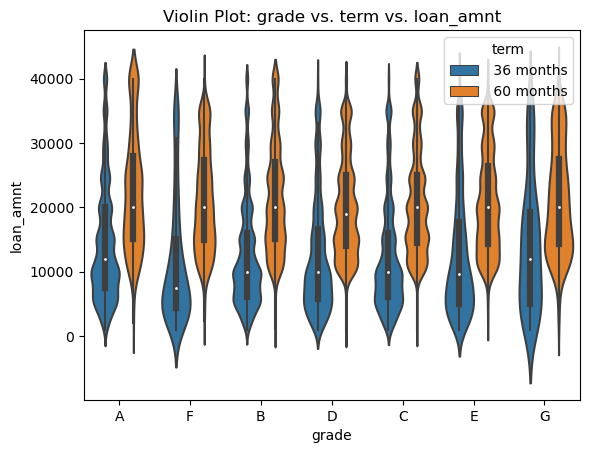

In [143]:
X1 = "grade"
X2 = "term" 
Y = "loan_amnt"

plot_3_variable_relationship(EDA_df,X1,X2,Y)

### Data Cleaning
This part includes:Removing Exclusions, Missing Value Imputation, Removing Outliers

In [144]:
complete_df.dtypes

id                     object
member_id             float64
loan_amnt             float64
funded_amnt           float64
funded_amnt_inv       float64
                       ...   
settlement_term       float64
loan_condition_int      int32
loan_condition         object
emp_length_int        float64
region                 object
Length: 155, dtype: object

In [145]:
pd.value_counts(complete_df.loan_status).to_frame().reset_index()

,loan_status,count
0,Fully Paid,47718
1,Current,38822
2,Charged Off,11868
3,Late (31-120 days),946
4,In Grace Period,335
5,Late (16-30 days),185
6,Does not meet the credit policy. Status:Fully ...,88
7,Does not meet the credit policy. Status:Charge...,36
8,Default,2


Ajustment 1: change the classification of good loans and bad loans

Current and Issued should be excluded, as they did not indicate the direction of the loans (it was unclear whether they were associated with good or bad loans).

In [146]:
drop_df = complete_df
drop_df = complete_df[~complete_df['loan_status'].isin(['Current', 'Issued',
                                #  'In Grace Period', 'Late (16-30 days)', 'Late (31-120 days)',
                                # 'Does not meet the credit policy. Status:Fully Paid', 'Does not meet the credit policy. Status:Charged Off'
                                                           ])]

In [147]:
#Delete variables with more than 80% missing values
def get_missing_value_stats(input_df):
    df_null = pd.DataFrame({
        'Missing Count': input_df.isnull().sum(),
        'Missing Percent': 100 * input_df.isnull().sum() / len(input_df),
        'Type': input_df.dtypes
    })
    missing_values = df_null[df_null['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False) #改
    return missing_values

def get_value_stats(input_df):
    df_null = pd.DataFrame({
        '#Count': input_df.notna().sum(),
        '%Populated': 100 * input_df.notna().sum() / len(input_df),
        '#Unique Values':input_df.nunique(),
        'Most Common Value': input_df.mode().iloc[0],
        'Type': input_df.dtypes
    })

    missing_values = df_null[df_null['#Count'] > 0].sort_values(by='#Count', ascending=False)

    return missing_values

# Finding the the count and percentage of values that are missing.
get_missing_value_stats(drop_df)

,Missing Count,Missing Percent,Type
member_id,61178,100.000000,float64
orig_projected_additional_accrued_interest,60930,99.594626,float64
sec_app_mths_since_last_major_derog,60832,99.434437,float64
hardship_reason,60824,99.421361,object
hardship_dpd,60824,99.421361,float64
...,...,...,...
dti,28,0.045768,float64
chargeoff_within_12_mths,5,0.008173,float64
collections_12_mths_ex_med,5,0.008173,float64
tax_liens,5,0.008173,float64


In [148]:
#drop any columns where over a certain percentage is missing
drop_df = drop_df.dropna(axis=1, thresh=int(0.20*len(drop_df)))
get_missing_value_stats(drop_df)

,Missing Count,Missing Percent,Type
mths_since_recent_bc_dlq,46552,76.092713,float64
mths_since_last_major_derog,44984,73.529700,float64
mths_since_recent_revol_delinq,40485,66.175749,float64
il_util,39485,64.541175,float64
mths_since_rcnt_il,36807,60.163784,float64
...,...,...,...
dti,28,0.045768,float64
collections_12_mths_ex_med,5,0.008173,float64
tax_liens,5,0.008173,float64
chargeoff_within_12_mths,5,0.008173,float64


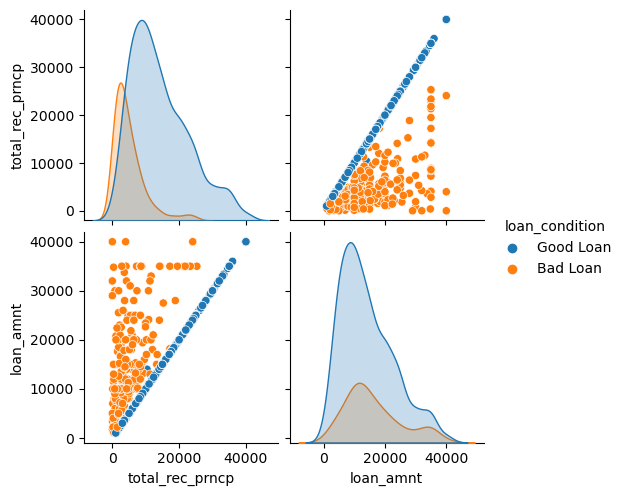

In [149]:
#Delete dynamic indicators
sns.pairplot(drop_df[['total_rec_prncp', 'loan_condition', 'loan_amnt']].sample(n=1000, random_state=42), hue='loan_condition')

In [150]:
direct_indicators = [
    'collection_recovery_fee',
    'last_pymnt_amnt',
    'out_prncp',
    'out_prncp_inv',
    'recoveries',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_int',
    'total_rec_late_fee',
    'total_rec_prncp'
]

drop_df.drop(direct_indicators, axis=1, inplace=True)

In [151]:
#drop repeated features
# drop_df.drop(['loan_condition'], axis=1, inplace=True)
# drop_df.drop(['loan_status'], axis=1, inplace=True)
drop_df.drop(['emp_length'], axis=1, inplace=True)

drop_df.drop(['id','emp_title','url','title','zip_code'], axis=1, inplace=True)

# unique values a categorical variable (object) has
drop_df.select_dtypes(include=["object"]).nunique()  #include/exclude

term                      2
grade                     7
sub_grade                35
home_ownership            6
verification_status       3
issue_d                 138
loan_status               8
pymnt_plan                2
purpose                  14
addr_state               50
earliest_cr_line        630
initial_list_status       2
last_pymnt_d            134
last_credit_pull_d      123
application_type          2
hardship_flag             2
disbursement_method       2
debt_settlement_flag      2
loan_condition            2
region                    5
dtype: int64

In [152]:
#Missing Value Imputation
fillna_df = drop_df.copy()

# for object variables - Get the mode of next payment date and last payment date and the last date credit amount was pulled
for column in ["last_pymnt_d", "last_credit_pull_d"]:  #, 'income_category'
    fillna_df[column] = fillna_df.groupby("region")[column].transform(lambda x: x.fillna(x.mode()))

# for numerical variables
# Get the mode on the number of accounts in which the client is delinquent
fillna_df["pub_rec"] = fillna_df.groupby("region")["pub_rec"].transform(lambda x: x.fillna(x.median()))
# Get the mode of the total number of credit lines the borrower has
fillna_df["total_acc"] = fillna_df.groupby("region")["total_acc"].transform(lambda x: x.fillna(x.median()))

fillna_df["emp_length_int"] = fillna_df.groupby("region")["emp_length_int"].transform(lambda x: x.fillna(x.median()))

# Get the mean of the annual income depending on the region the client is located.
fillna_df["annual_inc"] = fillna_df.groupby("region")["annual_inc"].transform(lambda x: x.fillna(x.mean()))
# Mode of credit delinquencies in the past two years.
fillna_df["delinq_2yrs"] = fillna_df.groupby("region")["delinq_2yrs"].transform(lambda x: x.fillna(x.mean()))

In [153]:
# for other, fill in with zero
fillna_df.fillna(0, inplace=True)
fillna_df.isnull().sum().max() # Maximum number of nulls.

0

In [154]:
len(fillna_df['loan_condition_int'])
# Loan Ratios (Imbalanced classes)
fillna_df['loan_condition_int'].value_counts()/len(fillna_df['loan_condition_int']) * 100

loan_condition_int
0    78.14247
1    21.85753
Name: count, dtype: float64

In [155]:
#Removing Outliers
#Custom thresholds
RemoveOutlier_df = fillna_df.copy()
print("Dataset before removing outlier:",RemoveOutlier_df.shape)
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['annual_inc'] <= 250000]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['dti'] <= 50]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['open_acc'] <= 40]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['total_acc'] <= 80]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['revol_util'] <= 120]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['revol_bal'] <= 250000]
RemoveOutlier_df.reset_index(drop=True, inplace=True)
print("Dataset after removing outlier:",RemoveOutlier_df.shape)

RemoveOutlier_df.head().transpose()

Dataset before removing outlier: (61178, 99)
Dataset after removing outlier: (60253, 99)


,0,1,2,3,4
loan_amnt,28000.0,10650.0,3975.0,15000.0,8000.0
funded_amnt,28000.0,10650.0,3975.0,15000.0,8000.0
funded_amnt_inv,28000.0,10650.0,3975.0,15000.0,8000.0
term,36 months,36 months,36 months,36 months,36 months
int_rate,6.62,25.11,17.99,6.24,9.67
...,...,...,...,...,...
debt_settlement_flag,N,N,N,N,N
loan_condition_int,0,0,0,0,0
loan_condition,Good Loan,Good Loan,Good Loan,Good Loan,Good Loan
emp_length_int,10.0,10.0,2.0,8.0,10.0


In [156]:
#Correlation Analysis
target_col = target_variable = "loan_condition_int"

In [157]:
corr_df = RemoveOutlier_df.copy() 
# Check and convert to numeric if needed
corr_df[target_variable] = pd.to_numeric(corr_df[target_variable], errors='coerce')

In [158]:
corr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60253 entries, 0 to 60252
Data columns (total 99 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   loan_amnt                       60253 non-null  float64
 1   funded_amnt                     60253 non-null  float64
 2   funded_amnt_inv                 60253 non-null  float64
 3   term                            60253 non-null  object 
 4   int_rate                        60253 non-null  float64
 5   installment                     60253 non-null  float64
 6   grade                           60253 non-null  object 
 7   sub_grade                       60253 non-null  object 
 8   home_ownership                  60253 non-null  object 
 9   annual_inc                      60253 non-null  float64
 10  verification_status             60253 non-null  object 
 11  issue_d                         60253 non-null  object 
 12  loan_status                     

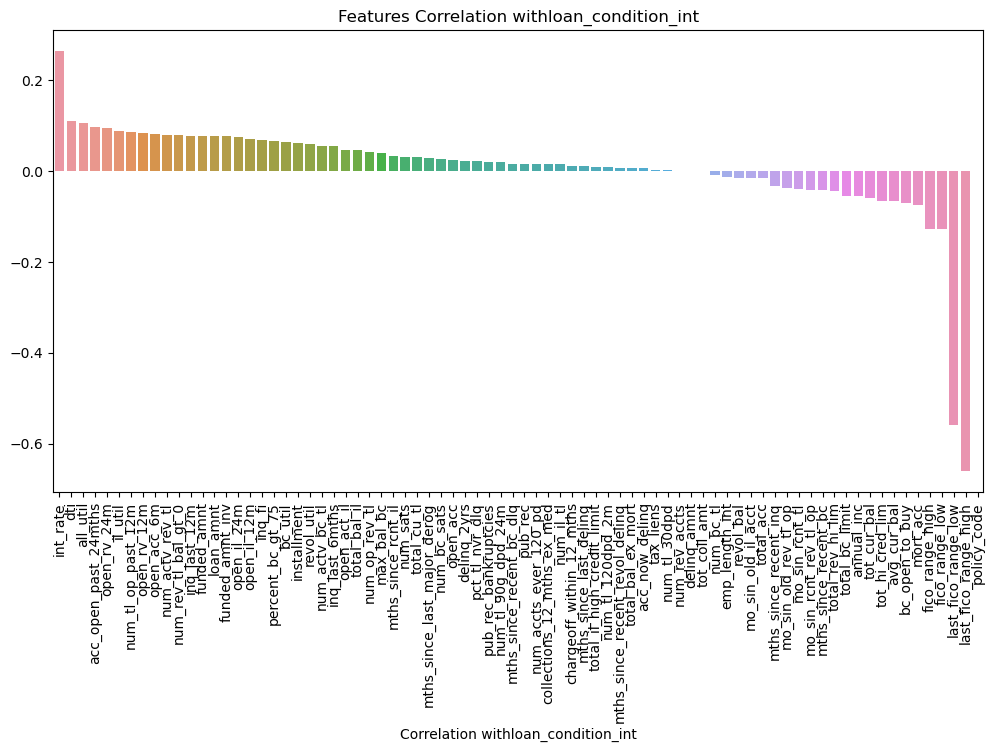

int_rate                0.263249
dti                     0.108784
all_util                0.104183
acc_open_past_24mths    0.095598
open_rv_24m             0.095068
                          ...   
fico_range_high        -0.127440
fico_range_low         -0.127441
last_fico_range_low    -0.559323
last_fico_range_high   -0.660207
policy_code                  NaN
Name: loan_condition_int, Length: 78, dtype: float64


In [159]:
# correlation with y
correlation_with_loan_condition = corr_df.select_dtypes(include=['int32', 'float64']).corr()[target_variable]
sorted_correlation = correlation_with_loan_condition.drop(target_variable).sort_values(ascending=False)

# plot
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_correlation.index, y=sorted_correlation.values, orient='v')
plt.xlabel('Correlation with{}'.format(target_variable))
plt.title('Features Correlation with{}'.format(target_variable))
plt.xticks(rotation=90)
plt.show()
print(sorted_correlation)


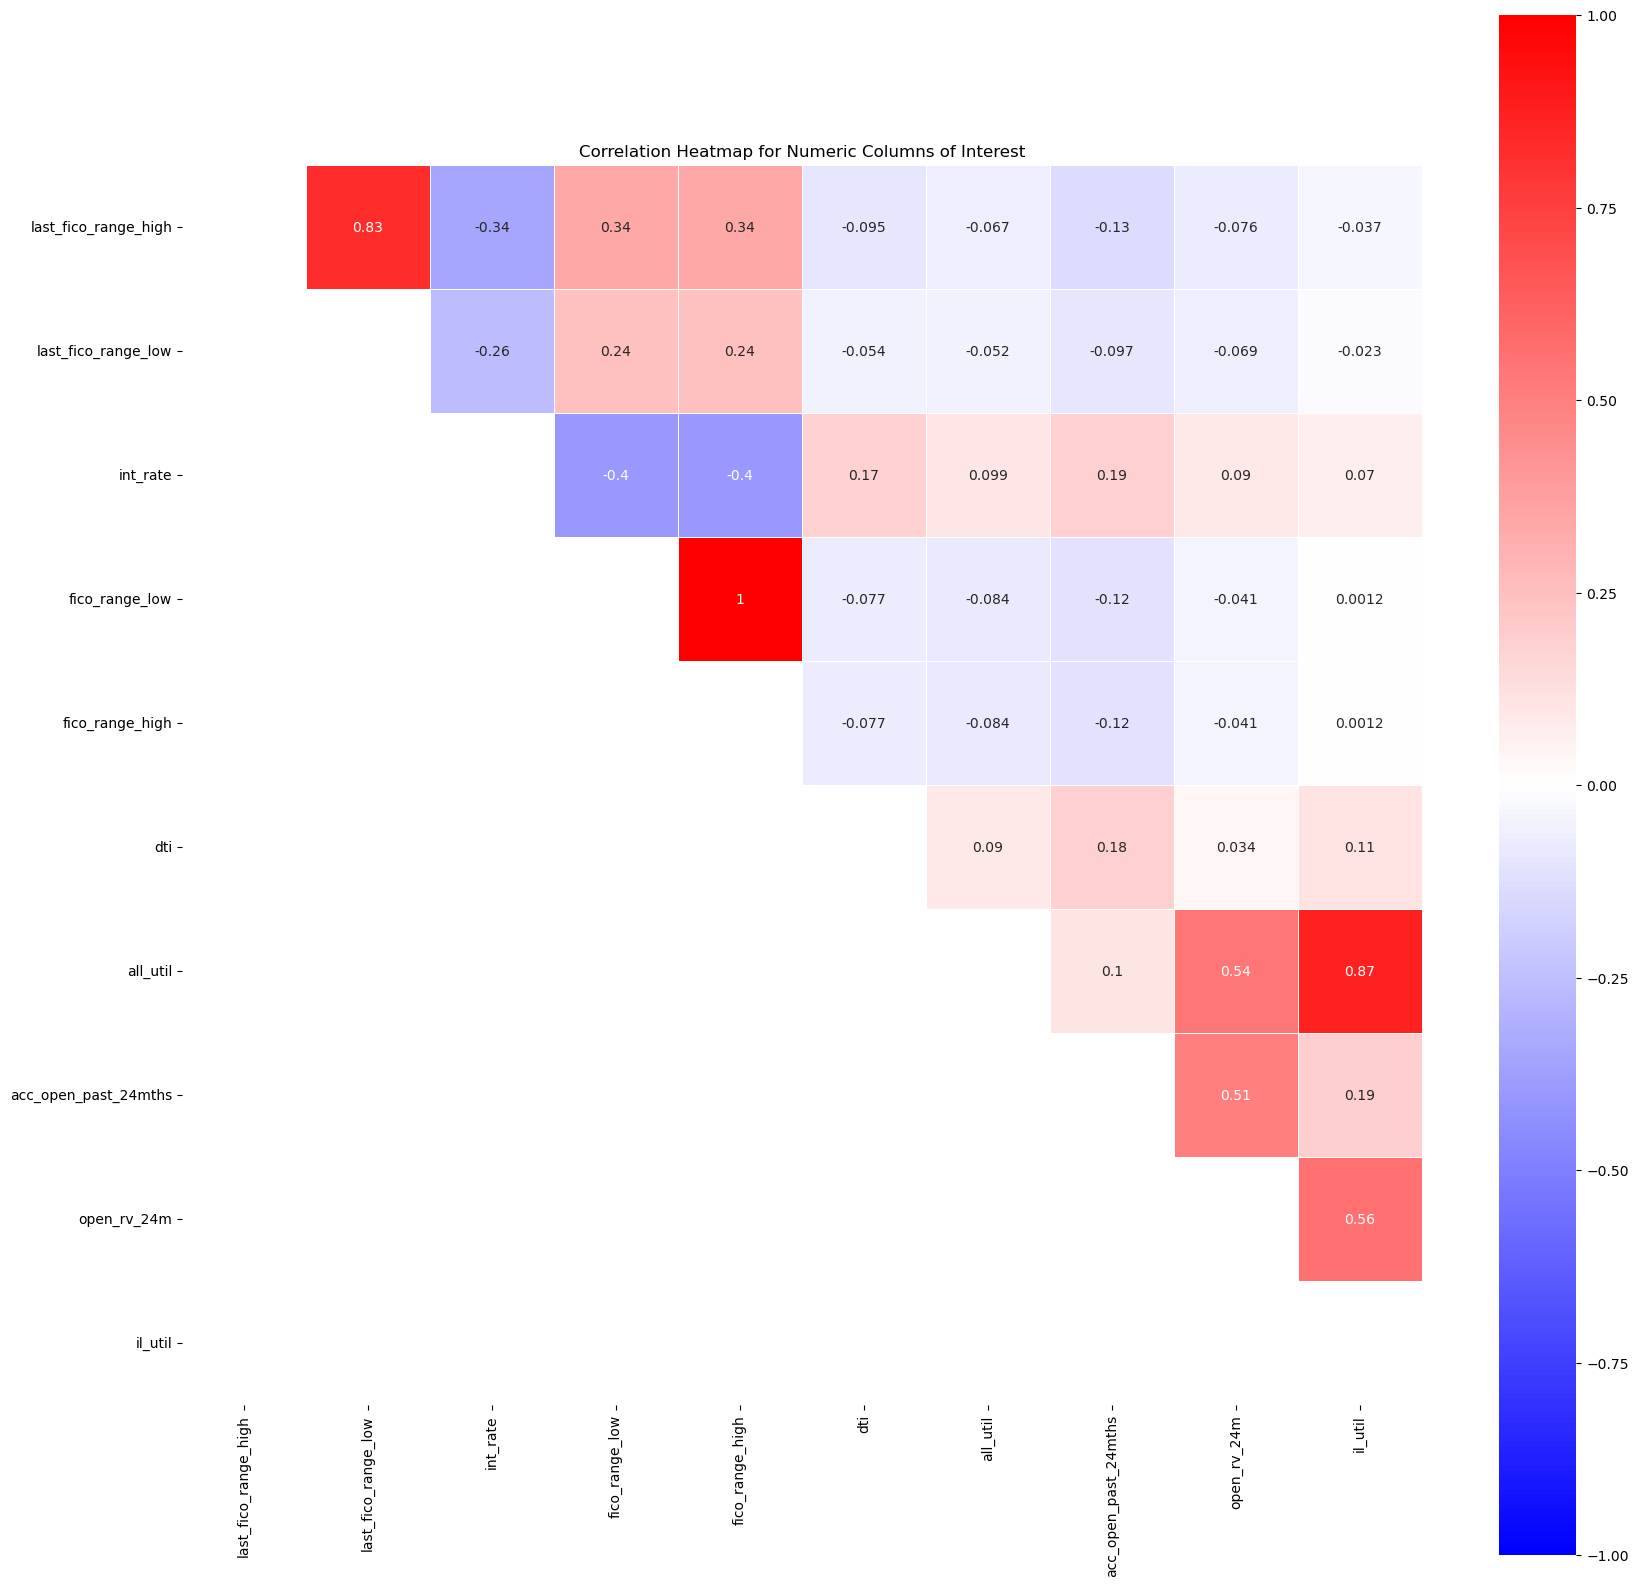

In [160]:
# Select the variables with the highest correlation with the dependent variable and explore the correlation between them
top_variables = sorted_correlation.abs().nlargest(10).index.tolist()

plt.figure(figsize=(20, 20))
correlation_matrix = RemoveOutlier_df[top_variables].corr()
mask = np.tril(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, annot=True, cmap='bwr', vmin=-1, vmax=1, square=True, linewidths=0.5, mask=mask)
plt.title('Correlation Heatmap for Numeric Columns of Interest')
plt.show()

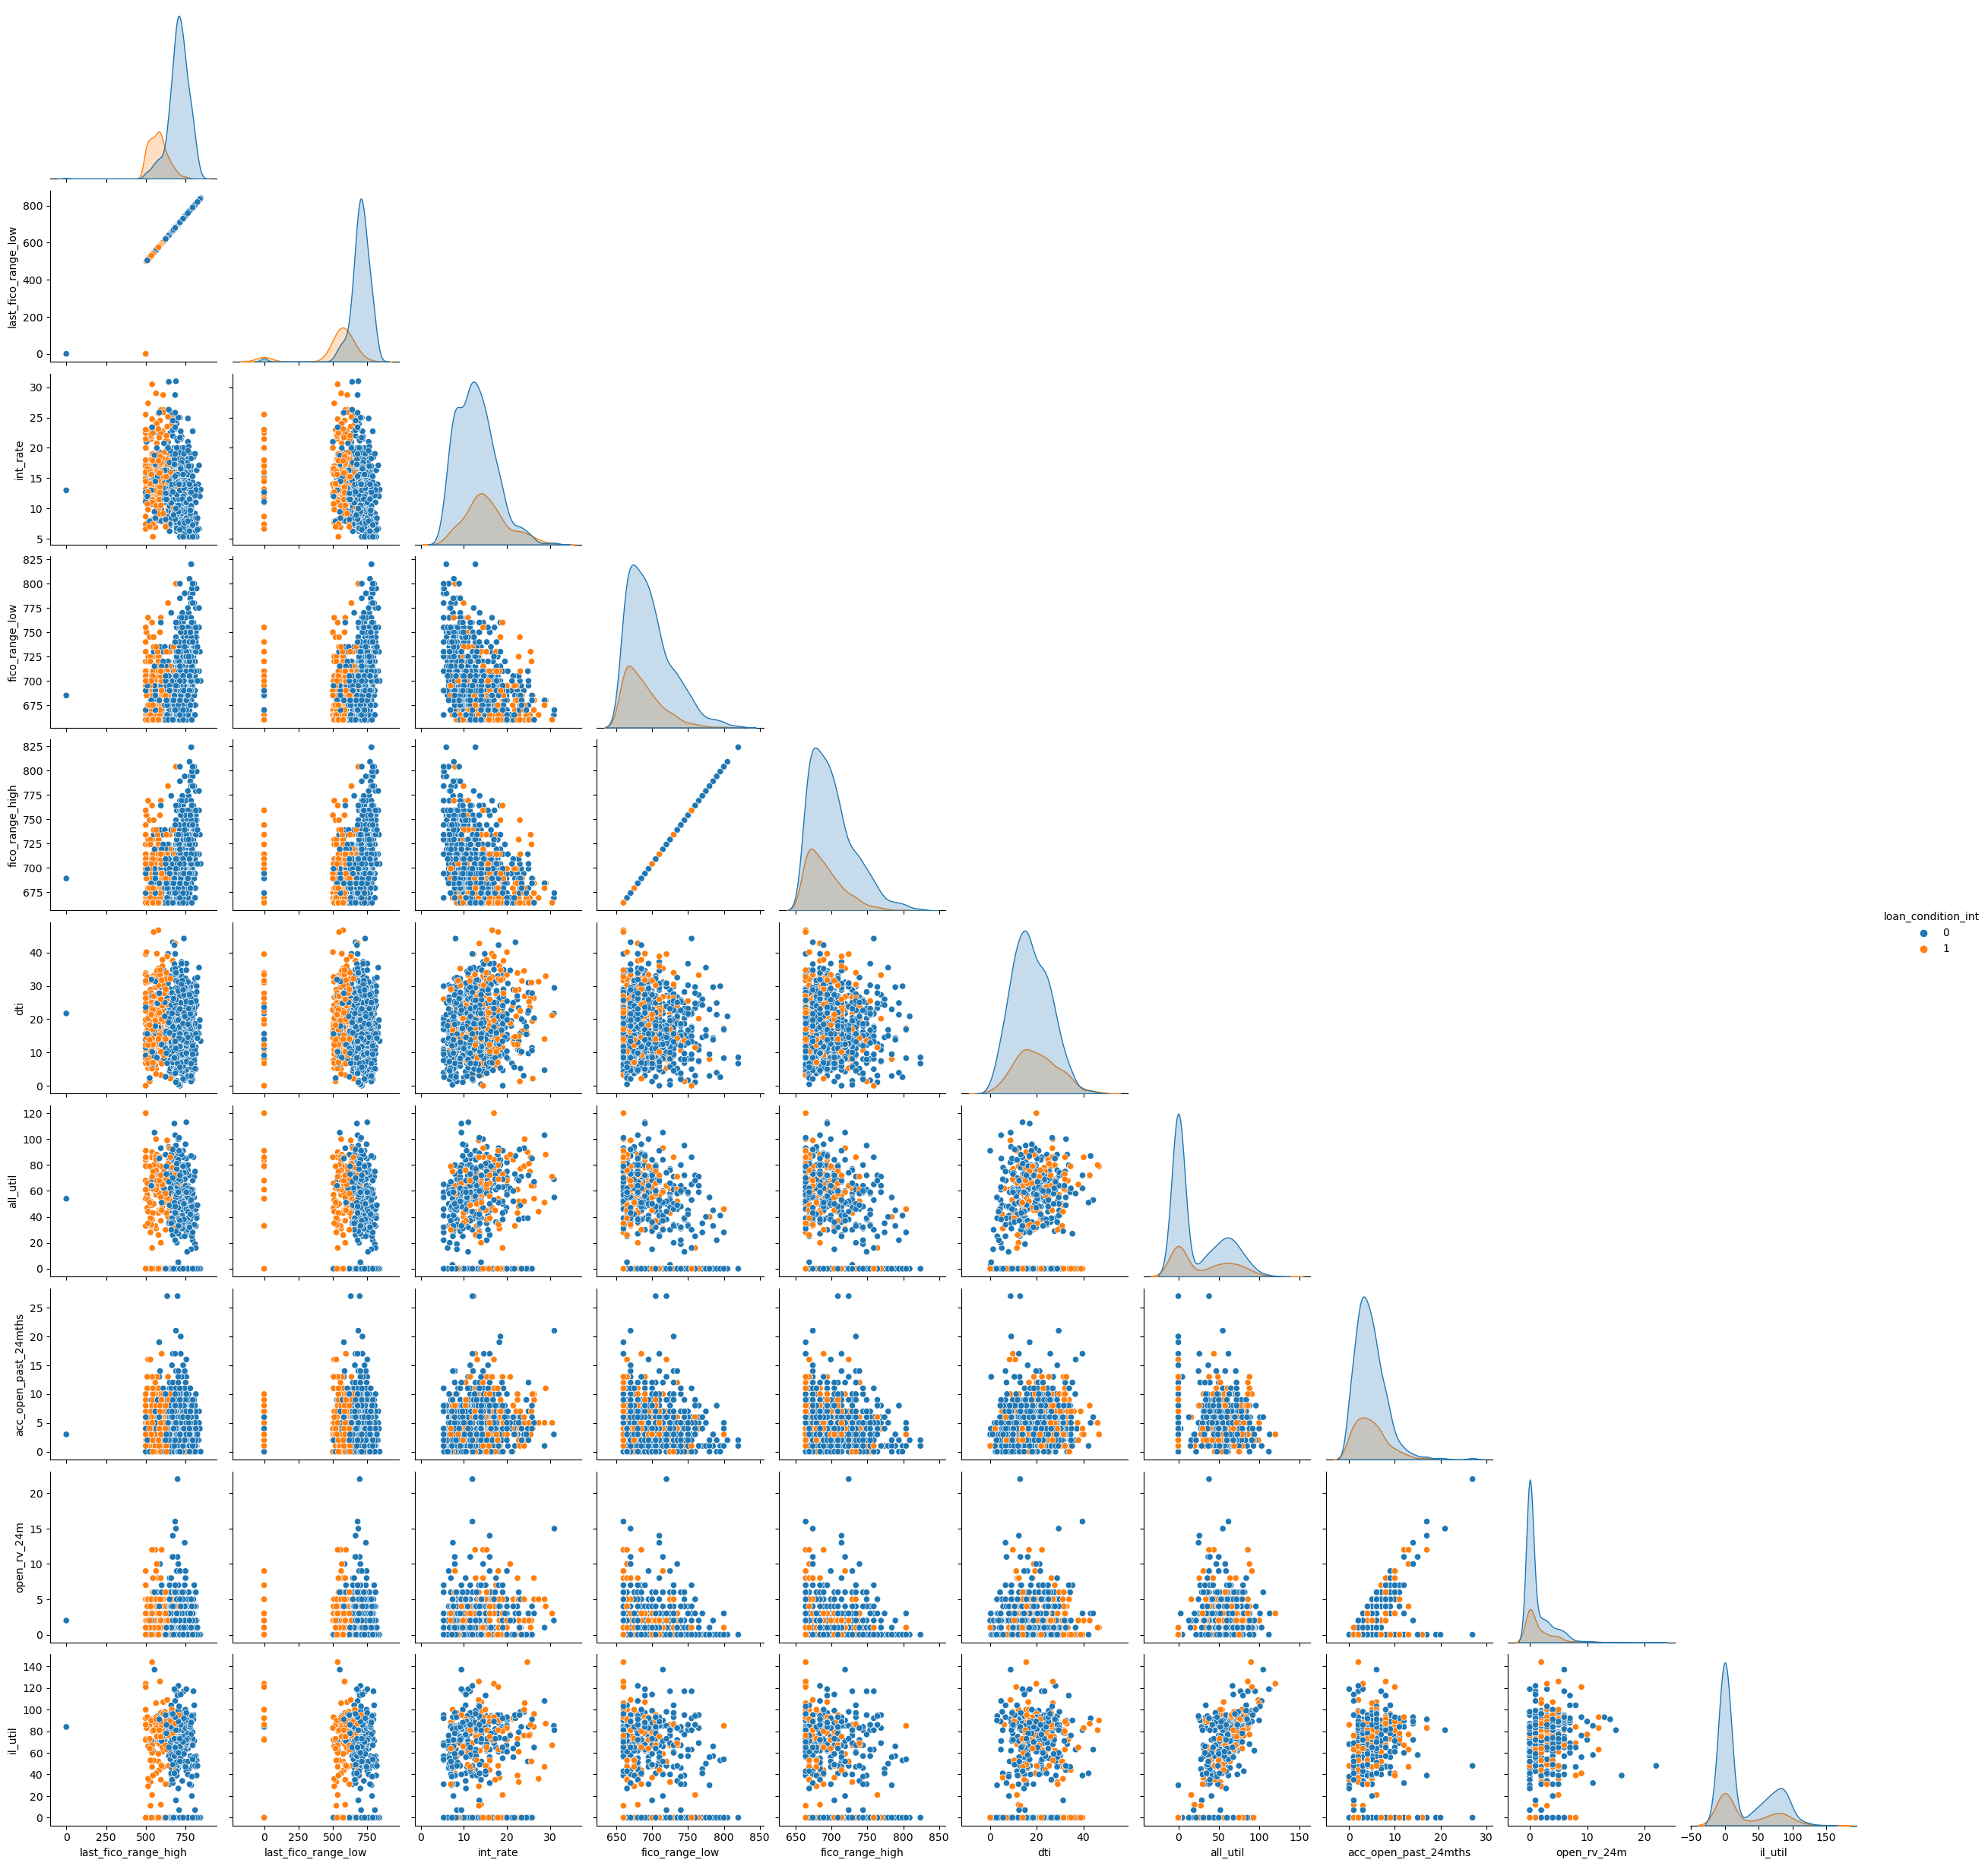

In [161]:
# # Further, explore the specific distribution of the relationship between variables under the action of the dependent variable loan_condition_int
# # This runs a bit slowly, so run with caution
sample_corr_df = corr_df[top_variables + [target_variable]].sample(n=1000, random_state=42)
sns.pairplot(sample_corr_df,hue=target_variable, diag_kind='kde',corner=True)

### Checking the data, Handling imbalance, model building, model training and testing, prediction using the trained model

In [183]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [184]:
df = pd.read_csv("Data/accepted_2007_to_2018Q4.csv")
df = df.dropna(subset=["loan_status"])
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260668 entries, 0 to 2260698
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.6+ GB


In [186]:
for feature in df.columns:
    print(feature)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

In [187]:
miss=df.isna().sum()
missing_entries_sorted = miss.sort_values(ascending=False)
print(missing_entries_sorted)

member_id                                     2260668
orig_projected_additional_accrued_interest    2252017
hardship_end_date                             2249751
hardship_start_date                           2249751
hardship_type                                 2249751
                                               ...   
policy_code                                         0
revol_bal                                           0
fico_range_high                                     0
fico_range_low                                      0
id                                                  0
Length: 151, dtype: int64


In [188]:
lower=1130351
high=2260701

missing_num=df.isnull().sum()

features_to_drop=missing_num[(missing_num>=lower)& (missing_num<=high)].index
df=df.drop(columns=features_to_drop)

print("Dropped Features:" , features_to_drop)

Dropped Features: Index(['member_id', 'desc', 'mths_since_last_delinq', 'mths_since_last_record',
       'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint',
       'dti_joint', 'verification_status_joint', 'mths_since_recent_bc_dlq',
       'mths_since_recent_revol_delinq', 'revol_bal_joint',
       'sec_app_fico_range_low', 'sec_app_fico_range_high',
       'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths',
       'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util',
       'sec_app_open_act_il', 'sec_app_num_rev_accts',
       'sec_app_chargeoff_within_12_mths',
       'sec_app_collections_12_mths_ex_med',
       'sec_app_mths_since_last_major_derog', 'hardship_type',
       'hardship_reason', 'hardship_status', 'deferral_term',
       'hardship_amount', 'hardship_start_date', 'hardship_end_date',
       'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
       'hardship_loan_status', 'orig_projected_additional_accrued_interest',
       'hardship_

In [189]:
df

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,...,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,...,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260694,89885898,24000.0,24000.0,24000.0,60 months,12.79,543.50,C,C1,Unit Operator,...,NaN,0.0,0.0,102517.0,104422.0,0.0,52017.0,N,Cash,N
2260695,88977788,24000.0,24000.0,24000.0,60 months,10.49,515.74,B,B3,Database Administrator,...,42.9,0.0,1.0,227883.0,140118.0,27900.0,172283.0,N,Cash,N
2260696,88985880,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,Vice President,...,50.0,0.0,0.0,55970.0,28398.0,12300.0,42670.0,N,Cash,N
2260697,88224441,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,Program Manager,...,40.0,1.0,0.0,84664.0,62426.0,20700.0,58764.0,N,Cash,Y


In [190]:
#Dropping the rows with more than 70% of missing values
threshold=df.shape[1]*0.7

df=df.dropna(thresh=threshold)

print("Data after dropping rows with more than 70% missing values:")
df

Data after dropping rows with more than 70% missing values:


,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,...,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,...,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260694,89885898,24000.0,24000.0,24000.0,60 months,12.79,543.50,C,C1,Unit Operator,...,NaN,0.0,0.0,102517.0,104422.0,0.0,52017.0,N,Cash,N
2260695,88977788,24000.0,24000.0,24000.0,60 months,10.49,515.74,B,B3,Database Administrator,...,42.9,0.0,1.0,227883.0,140118.0,27900.0,172283.0,N,Cash,N
2260696,88985880,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,Vice President,...,50.0,0.0,0.0,55970.0,28398.0,12300.0,42670.0,N,Cash,N
2260697,88224441,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,Program Manager,...,40.0,1.0,0.0,84664.0,62426.0,20700.0,58764.0,N,Cash,Y


In [191]:
for features in df.isna().sum():
    print(features)

0
0
0
0
0
0
0
0
0
162631
144846
0
0
0
0
0
0
0
0
23313
1
0
1711
0
0
0
0
1
0
0
0
1681
0
0
0
0
0
0
0
0
0
0
0
2313
0
68
0
0
0
0
0
0
0
0
795854
795853
795853
795853
839648
795853
998574
795853
795853
795853
796072
0
795853
795854
795854
0
70
24634
25757
0
0
68795
1
1
0
0
23143
242744
0
0
0
0
0
0
0
1
0
0
83381
0
0
0
155
25078
0
0
0
0
0
0
0
0
0


In [192]:
lower=100000
high=800000

missing_num1=df.isnull().sum()

features_to_drop=missing_num1[(missing_num1>=lower)& (missing_num1<=high)].index
df=df.drop(columns=features_to_drop)

print("Dropped Features:" , features_to_drop)

Dropped Features: Index(['emp_title', 'emp_length', 'open_acc_6m', 'open_act_il', 'open_il_12m',
       'open_il_24m', 'total_bal_il', 'open_rv_12m', 'open_rv_24m',
       'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'mths_since_recent_inq'],
      dtype='object')


In [193]:
df

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,MORTGAGE,...,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,MORTGAGE,...,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,MORTGAGE,...,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,MORTGAGE,...,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,MORTGAGE,...,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260694,89885898,24000.0,24000.0,24000.0,60 months,12.79,543.50,C,C1,MORTGAGE,...,NaN,0.0,0.0,102517.0,104422.0,0.0,52017.0,N,Cash,N
2260695,88977788,24000.0,24000.0,24000.0,60 months,10.49,515.74,B,B3,MORTGAGE,...,42.9,0.0,1.0,227883.0,140118.0,27900.0,172283.0,N,Cash,N
2260696,88985880,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,MORTGAGE,...,50.0,0.0,0.0,55970.0,28398.0,12300.0,42670.0,N,Cash,N
2260697,88224441,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,RENT,...,40.0,1.0,0.0,84664.0,62426.0,20700.0,58764.0,N,Cash,Y


In [194]:
df.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url',
       'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'fico_range_low', 'fico_range_high',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d',
       'last_fico_range_high', 'last_fico_range_low',
       'collections_12_mths_ex_med', 'policy_code', 'application_type',
       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'mths_since_rcnt_il',
       'il_util', 'total_rev_hi_lim', 'acc_open_past_24mths', 'av

In [195]:
df['debt_settlement_flag'].unique()

array(['N', 'Y'], dtype=object)

In [196]:
df['title'].nunique()

39098

In [197]:
#NO=0, YES=1
from sklearn.preprocessing import LabelEncoder

label_encoder=LabelEncoder()
df['Label']=label_encoder.fit_transform(df['debt_settlement_flag'])
df

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,Label
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,MORTGAGE,...,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,MORTGAGE,...,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,MORTGAGE,...,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,MORTGAGE,...,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N,0
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,MORTGAGE,...,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260694,89885898,24000.0,24000.0,24000.0,60 months,12.79,543.50,C,C1,MORTGAGE,...,0.0,0.0,102517.0,104422.0,0.0,52017.0,N,Cash,N,0
2260695,88977788,24000.0,24000.0,24000.0,60 months,10.49,515.74,B,B3,MORTGAGE,...,0.0,1.0,227883.0,140118.0,27900.0,172283.0,N,Cash,N,0
2260696,88985880,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,MORTGAGE,...,0.0,0.0,55970.0,28398.0,12300.0,42670.0,N,Cash,N,0
2260697,88224441,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,RENT,...,1.0,0.0,84664.0,62426.0,20700.0,58764.0,N,Cash,Y,1


In [232]:
#!pip install lightgbm

In [231]:
#!pip uninstall pandas -y
#!pip install --no-cache-dir pandas==1.5.3
#!pip uninstall pandas dask -y
#!pip install pandas==1.5.3 dask==2023.3.2

In [206]:
#Checking the feature importance 
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Initialize LabelEncoder for each categorical column
label_encoders = {}
for col in categorical_columns:
    df[col] = df[col].astype(str)  # Ensure all entries are strings to avoid mixed types
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Split into features and target
X = df.drop('Label', axis=1)  # Replace 'Label' with your target column if named differently
y = df['Label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize LGBMClassifier with parameters
model = lgb.LGBMClassifier(
    objective='binary',  # Change to 'multiclass' if there is multiple classes
    metric='binary_logloss',
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature importance
importance = model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance}).sort_values(by='Importance', ascending=False)

[LightGBM] [Info] Number of positive: 27014, number of negative: 1725299
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.838996 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12148
[LightGBM] [Info] Number of data points in the train set: 1752313, number of used features: 91
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015416 -> initscore=-4.156800
[LightGBM] [Info] Start training from score -4.156800
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [207]:
drop_yes = importance_df[importance_df['Importance'] <= 5].index
importance_df = importance_df.drop(drop_yes)
print(importance_df)

                    Feature  Importance
0                        id         215
1                 loan_amnt         146
91     debt_settlement_flag         100
5                  int_rate          55
10               annual_inc          52
6               installment          42
3           funded_amnt_inv          39
18                 zip_code          30
17                    title          29
20                      dti          17
50             tot_coll_amt          12
66     mths_since_recent_bc          12
28                revol_bal          11
32                out_prncp          11
52       mths_since_rcnt_il           9
40  collection_recovery_fee           8
53                  il_util           6


In [208]:
importance_df['Feature'].tolist()

['id',
 'loan_amnt',
 'debt_settlement_flag',
 'int_rate',
 'annual_inc',
 'installment',
 'funded_amnt_inv',
 'zip_code',
 'title',
 'dti',
 'tot_coll_amt',
 'mths_since_recent_bc',
 'revol_bal',
 'out_prncp',
 'mths_since_rcnt_il',
 'collection_recovery_fee',
 'il_util']

In [210]:
features_to_keep = importance_df['Feature'].tolist()
additional_feature = 'Label'

if additional_feature not in features_to_keep:
    features_to_keep.append(additional_feature)

    
filtered_df = df[features_to_keep]
filtered_df

,id,loan_amnt,debt_settlement_flag,int_rate,annual_inc,installment,funded_amnt_inv,zip_code,title,dti,tot_coll_amt,mths_since_recent_bc,revol_bal,out_prncp,mths_since_rcnt_il,collection_recovery_fee,il_util,Label
0,1633051,3600.0,0,13.99,55000.0,123.03,3600.0,182,10681,5.91,722.0,4.0,2765.0,0.00,21.0,0.0,36.0,0
1,1630402,24700.0,0,11.99,65000.0,820.28,24700.0,553,2861,16.06,0.0,2.0,21470.0,0.00,19.0,0.0,73.0,0
2,1630131,20000.0,0,10.78,63000.0,432.66,20000.0,578,35955,10.78,0.0,101.0,7869.0,0.00,19.0,0.0,73.0,0
3,1595559,35000.0,0,14.85,110000.0,829.90,35000.0,69,10681,17.06,0.0,2.0,7802.0,15897.65,23.0,0.0,70.0,0
4,1635854,10400.0,0,22.45,104433.0,289.91,10400.0,166,19180,25.37,0.0,4.0,21929.0,0.00,14.0,0.0,84.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260694,1991949,24000.0,0,12.79,95000.0,543.50,24000.0,346,16157,19.61,0.0,NaN,49431.0,14287.39,3.0,0.0,106.0,0
2260695,1983099,24000.0,0,10.49,108000.0,515.74,24000.0,804,10681,34.94,0.0,15.0,21665.0,13951.42,16.0,0.0,77.0,0
2260696,1983435,40000.0,0,10.49,227000.0,859.56,40000.0,861,35955,12.75,0.0,41.0,8633.0,23252.59,15.0,0.0,46.0,0
2260697,1966928,24000.0,1,14.49,110000.0,564.56,24000.0,324,10681,18.30,0.0,9.0,17641.0,0.00,20.0,0.0,78.0,1


In [211]:
filtered_df.isna().sum()

id                              0
loan_amnt                       0
debt_settlement_flag            0
int_rate                        0
annual_inc                      0
installment                     0
funded_amnt_inv                 0
zip_code                        0
title                           0
dti                          1711
tot_coll_amt                    0
mths_since_recent_bc        23143
revol_bal                       0
out_prncp                       0
mths_since_rcnt_il         839648
collection_recovery_fee         0
il_util                    998574
Label                           0
dtype: int64

In [212]:
columns_to_fill = ['dti', 'mths_since_recent_bc', 'mths_since_rcnt_il', 'il_util']

for column in columns_to_fill:
    filtered_df[column].fillna(filtered_df[column].mean(), inplace=True)

# Verify that missing values have been filled
print(filtered_df[columns_to_fill].isnull().sum())

dti                     0
mths_since_recent_bc    0
mths_since_rcnt_il      0
il_util                 0
dtype: int64


In [213]:
filtered_df.dropna(inplace=True)

In [214]:
filtered_df['Label'].value_counts()

Label
0    2156484
1      33908
Name: count, dtype: int64

In [215]:
filtered_df = filtered_df.drop(columns=['debt_settlement_flag', 'loan_amnt'], errors='ignore')
filtered_df

,id,int_rate,annual_inc,installment,funded_amnt_inv,zip_code,title,dti,tot_coll_amt,mths_since_recent_bc,revol_bal,out_prncp,mths_since_rcnt_il,collection_recovery_fee,il_util,Label
0,1633051,13.99,55000.0,123.03,3600.0,182,10681,5.91,722.0,4.00000,2765.0,0.00,21.0,0.0,36.0,0
1,1630402,11.99,65000.0,820.28,24700.0,553,2861,16.06,0.0,2.00000,21470.0,0.00,19.0,0.0,73.0,0
2,1630131,10.78,63000.0,432.66,20000.0,578,35955,10.78,0.0,101.00000,7869.0,0.00,19.0,0.0,73.0,0
3,1595559,14.85,110000.0,829.90,35000.0,69,10681,17.06,0.0,2.00000,7802.0,15897.65,23.0,0.0,70.0,0
4,1635854,22.45,104433.0,289.91,10400.0,166,19180,25.37,0.0,4.00000,21929.0,0.00,14.0,0.0,84.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260694,1991949,12.79,95000.0,543.50,24000.0,346,16157,19.61,0.0,24.85511,49431.0,14287.39,3.0,0.0,106.0,0
2260695,1983099,10.49,108000.0,515.74,24000.0,804,10681,34.94,0.0,15.00000,21665.0,13951.42,16.0,0.0,77.0,0
2260696,1983435,10.49,227000.0,859.56,40000.0,861,35955,12.75,0.0,41.00000,8633.0,23252.59,15.0,0.0,46.0,0
2260697,1966928,14.49,110000.0,564.56,24000.0,324,10681,18.30,0.0,9.00000,17641.0,0.00,20.0,0.0,78.0,1


In [216]:
from sklearn.utils import resample

# Separate majority and minority classes
majority_class = filtered_df[filtered_df['Label'] == 0]
minority_class = filtered_df[filtered_df['Label'] == 1]

In [217]:
minority_upsampled = resample(minority_class,
                              replace=True,       # Sample with replacement
                              n_samples=len(majority_class),  # Match majority class count
                              random_state=42)   # For reproducibility

# Combine majority class with upsampled minority class
balanced_df = pd.concat([majority_class, minority_upsampled])

# Shuffle the new balanced dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [218]:
balanced_df['Label'].value_counts()

Label
0    2156484
1    2156484
Name: count, dtype: int64

In [219]:
filtered_df=balanced_df

In [220]:
filtered_df['Label'].value_counts()

Label
0    2156484
1    2156484
Name: count, dtype: int64

In [221]:
X =filtered_df.drop('Label', axis=1)
y =filtered_df['Label']

In [222]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [223]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val=scaler.transform(X_val)

### LOGISTIC REGRESSION

In [224]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lg = LogisticRegression(C=0.01, random_state=42)
lg.fit(X_train, y_train)
lg_predictions = lg.predict(X_test)

# Evaluate the model
print("Logistic Regression Accuracy:", accuracy_score(y_test, lg_predictions))
print(classification_report(y_test, lg_predictions))

Logistic Regression Accuracy: 0.8284014430879857
              precision    recall  f1-score   support

           0       0.78      0.91      0.84    323188
           1       0.89      0.75      0.81    323758

    accuracy                           0.83    646946
   macro avg       0.84      0.83      0.83    646946
weighted avg       0.84      0.83      0.83    646946



In [225]:
y_val_pred = lg.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred)}")
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8278014359798747
              precision    recall  f1-score   support

           0       0.78      0.91      0.84    323923
           1       0.89      0.75      0.81    323022

    accuracy                           0.83    646945
   macro avg       0.84      0.83      0.83    646945
weighted avg       0.84      0.83      0.83    646945



In [226]:
import joblib
joblib.dump(lg, 'logistic_regression_model.joblib')
print("Model saved successfully!")

Model saved successfully!


In [227]:
# Load the saved model
lg_loaded = joblib.load('logistic_regression_model.joblib')
print("Model loaded successfully!")

Model loaded successfully!


In [233]:
#Use the loaded model for prediction
# Predict on new data or existing test set
y_pred_loaded = lg_loaded.predict(X_test)
print("Prediction from loaded model:", y_pred_loaded)

Prediction from loaded model: [0 1 1 ... 0 1 1]
